# Steam Gaming Trends — 01: Data Profiling

**Dataset**: Kaggle `fronkongames/steam-games-dataset` (CC0 Public Domain)  
Run `python data/download_data.py` first to populate `data/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA = Path('data')
FIG  = Path('outputs/figures')
FIG.mkdir(parents=True, exist_ok=True)

for f in [DATA / 'games.csv', DATA / 'recommendations.csv']:
    if not f.exists():
        raise FileNotFoundError(f'{f} not found — run data/fetch_steam_public.py')

## 1. Load games.csv

In [2]:
games = pd.read_csv(DATA / 'games.csv', low_memory=False)
print(f'games.csv: {len(games):,} rows × {games.shape[1]} columns')
games.dtypes

games.csv: 40 rows × 10 columns


app_id                       int64
name                        object
price                      float64
positive                     int64
negative                     int64
total_reviews                int64
review_score_desc           object
median_playtime_forever    float64
genres                      object
release_date                object
dtype: object

In [3]:
games.head(3)

,app_id,name,price,positive,negative,total_reviews,review_score_desc,median_playtime_forever,genres,release_date
0,730,Counter-Strike 2,0.0,4367665,746704,5114369,Very Positive,4966.0,Action;Free To Play,"Aug 21, 2012"
1,570,Dota 2,0.0,12192,2186,14378,Very Positive,33508.5,Action;Strategy;Free To Play,"Jul 9, 2013"
2,578080,PUBG: BATTLEGROUNDS,0.0,982955,777212,1760167,Mixed,2265.0,Action;Adventure;Massively Multiplayer;Free To...,"Dec 21, 2017"


## 2. Null Audit — games.csv

In [4]:
null_pct = games.isnull().mean().sort_values(ascending=False).mul(100).round(1)
null_pct[null_pct > 0]

Series([], dtype: float64)

## 3. Distributions of Key Numeric Columns

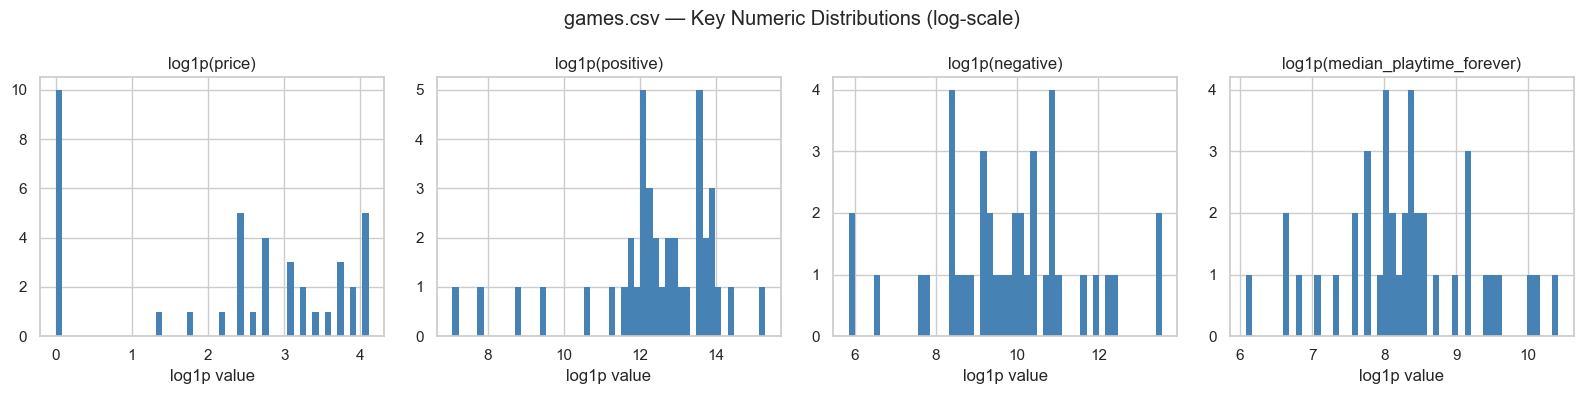

In [5]:
num_cols = ['price', 'positive', 'negative', 'median_playtime_forever', 'peak_ccu']
present = [c for c in num_cols if c in games.columns]

fig, axes = plt.subplots(1, len(present), figsize=(4 * len(present), 4))
for ax, col in zip(axes, present):
    data = games[col].dropna()
    # log-scale for heavy right tails
    data_log = np.log1p(data)
    ax.hist(data_log, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel('log1p value')
fig.suptitle('games.csv — Key Numeric Distributions (log-scale)')
fig.tight_layout()
fig.savefig(FIG / 'prof01_games_distributions.png', dpi=150)
plt.show()

## 4. Load recommendations.csv (sample)

The full recommendations file is ~41 M rows. We load a 500k sample for profiling — the full file is used in notebook 03.

In [6]:
recs_sample = pd.read_csv(DATA / 'recommendations.csv', nrows=500_000, low_memory=False)
print(f'recommendations.csv sample: {len(recs_sample):,} rows × {recs_sample.shape[1]} columns')
recs_sample.dtypes

recommendations.csv sample: 4,800 rows × 5 columns


app_id                int64
review               object
is_recommended         bool
playtime_forever      int64
timestamp_created     int64
dtype: object

In [7]:
recs_sample.head(3)

,app_id,review,is_recommended,playtime_forever,timestamp_created
0,730,hackers,False,3328,1780937238
1,730,Lol!,True,6708,1780937165
2,730,bullets are gay never go straight,True,459,1780937155


## 5. Null Audit — recommendations sample

In [8]:
recs_sample.isnull().mean().sort_values(ascending=False).mul(100).round(1)

review               0.3
app_id               0.0
is_recommended       0.0
playtime_forever     0.0
timestamp_created    0.0
dtype: float64

## 6. Class Balance (recommended flag)

is_recommended
True     89.2
False    10.8
Name: proportion, dtype: float64


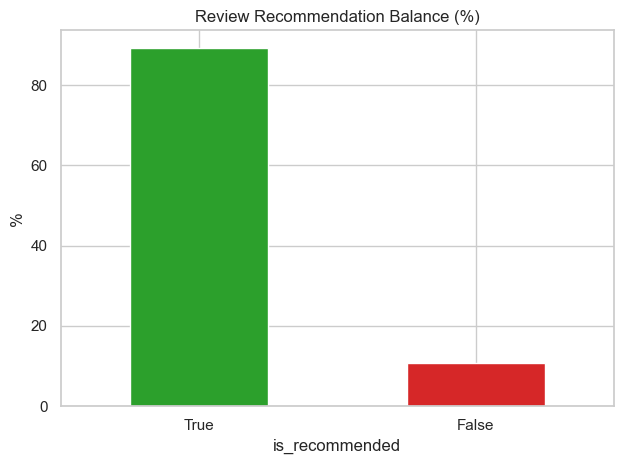

In [9]:
balance = recs_sample['is_recommended'].value_counts(normalize=True).mul(100).round(1)
print(balance)
balance.plot(kind='bar', color=['#2ca02c', '#d62728'])
plt.title('Review Recommendation Balance (%)')
plt.xlabel('is_recommended')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / 'prof02_class_balance.png', dpi=150)
plt.show()

**Note**: The dataset is heavily imbalanced — positive (recommended) reviews substantially outnumber negative ones. This must be accounted for in the P17 classifier (class weighting or under-sampling).